### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [1]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [2]:
import numpy as np
import pandas as pd

df = pd.DataFrame(lista_alumnos, columns = ["Nombre", "Edad", "Altura"])
df

,Nombre,Edad,Altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90
5,Miguel N,27,1.80
6,Alejandro M,28,1.70
7,Cristina M,32,1.60
8,Francisco P,36,1.74
9,Jorge D,45,1.72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nombre  21 non-null     object 
 1   Edad    21 non-null     int64  
 2   Altura  21 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 636.0+ bytes


In [3]:
df.describe()

,Edad,Altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


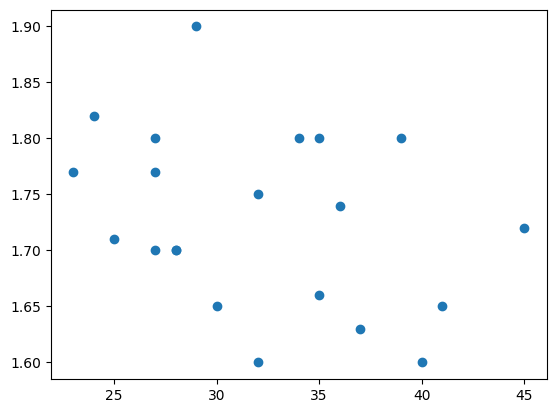

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["Edad"], df["Altura"])

<Axes: xlabel='Edad', ylabel='Altura'>

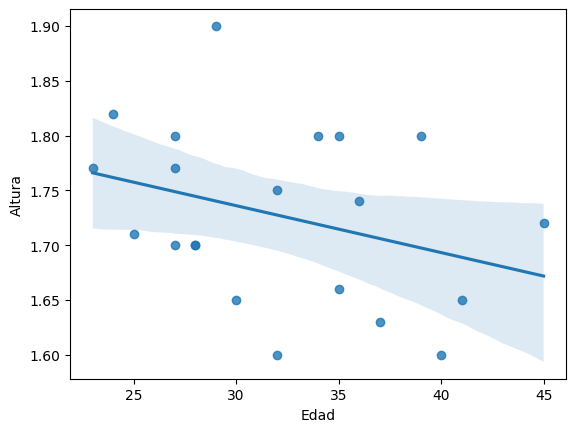

In [5]:
import seaborn as sns

sns.regplot(data = df, x = "Edad", y = "Altura")

<Axes: >

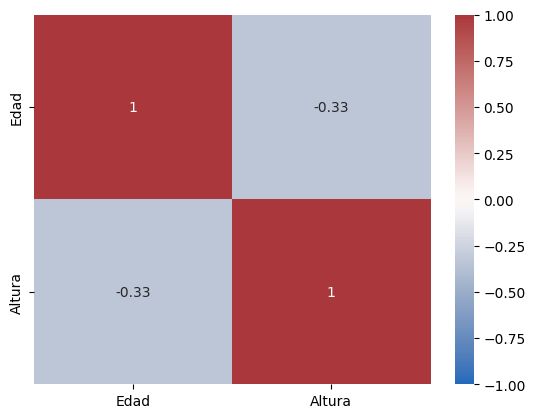

In [7]:
sns.heatmap(df.corr(numeric_only= True), annot= True, cmap="vlag", vmin=-1)

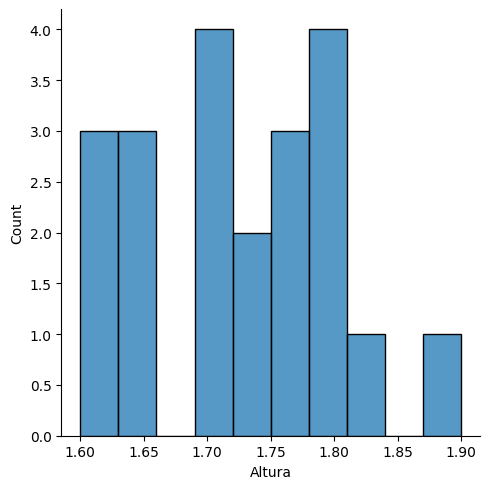

In [8]:
sns.displot(df["Altura"], bins = 10)

### Entrena un modelo de regresión lineal

In [9]:
X = df[["Edad"]]
y  = df["Altura"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 2, random_state=10)

In [43]:
print("Tamaño X train:", X_train.shape)
print("Tamaño y train:", y_train.shape)
print("Tamaño X test:", X_test.shape)
print("Tamaño y test:", y_test.shape)

Tamaño X train: (19, 1)
Tamaño y train: (19,)
Tamaño X test: (2, 1)
Tamaño y test: (2,)


In [44]:
y_test

14    1.77
5     1.80
Name: Altura, dtype: float64

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

st_scaler = StandardScaler()
X_train_scaler = st_scaler.fit_transform(X_train)

X_train_scaler

array([[-1.33028834],
       [-1.16722073],
       [ 0.46345529],
       [ 0.7895905 ],
       [-0.51495032],
       [-0.84108553],
       [-0.67801793],
       [-0.02574752],
       [ 0.62652289],
       [ 2.09413132],
       [ 1.44186091],
       [-0.35188272],
       [ 1.2787933 ],
       [ 1.1157257 ],
       [-1.49335594],
       [-0.02574752],
       [-0.84108553],
       [ 0.30038769],
       [-0.84108553]])

In [45]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
X_train_min_max = min_max_scaler.fit_transform(X_train)
X_test_scaler_min_max = min_max_scaler.transform(X_test)
X_train_min_max

array([[0.52380952],
       [0.28571429],
       [0.38095238],
       [0.14285714],
       [0.61904762],
       [0.19047619],
       [0.19047619],
       [0.76190476],
       [0.47619048],
       [0.52380952],
       [0.57142857],
       [0.80952381],
       [0.04761905],
       [0.71428571],
       [0.14285714],
       [0.        ],
       [0.38095238],
       [0.23809524],
       [1.        ]])

In [46]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()
modelo_lr.fit(X_train_min_max, y_train)


LinearRegression()

In [47]:
predicciones = modelo_lr.predict(X_test_scaler_min_max)
predicciones

array([1.75779983, 1.74286514])

In [40]:
y_test

0     1.82
17    1.80
Name: Altura, dtype: float64

In [24]:
edad = min_max_scaler.transform([[31]])

c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [25]:
edad

array([[0.36363636]])

In [26]:
res = modelo_lr.predict(edad)
print(res)

[1.73038303]


### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error

In [28]:
import sklearn.metrics

In [48]:
mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
rmse = root_mean_squared_error(y_test, predicciones)
mape = mean_absolute_percentage_error(y_test, predicciones)
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("MAPE: ", mape)

MAE:  0.0346675148430875
MSE:  0.0017066181860822917
RMSE:  0.04131123559132904
MAPE:  0.019317170061768404


In [33]:
# mean absolute error.

mae = abs(y_test - predicciones).mean()
mse  = ((y_test-predicciones)**2).mean()
mape = abs((y_test-predicciones)/y_test).mean()
print(mae)
print(mse)
print(mape)

0.067066882734237
0.004984394073530579
0.03799486598803739
